In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


# Introduction

This project focuses on transforming raw Brazilian E-commerce data into meaningful visualizations using Python.

The objective is to understand customer behavior, payment preferences, sales trends, product performance, and customer satisfaction through interactive and informative charts.

Tools Used:

- Python
- Pandas
- Matplotlib
- Seaborn

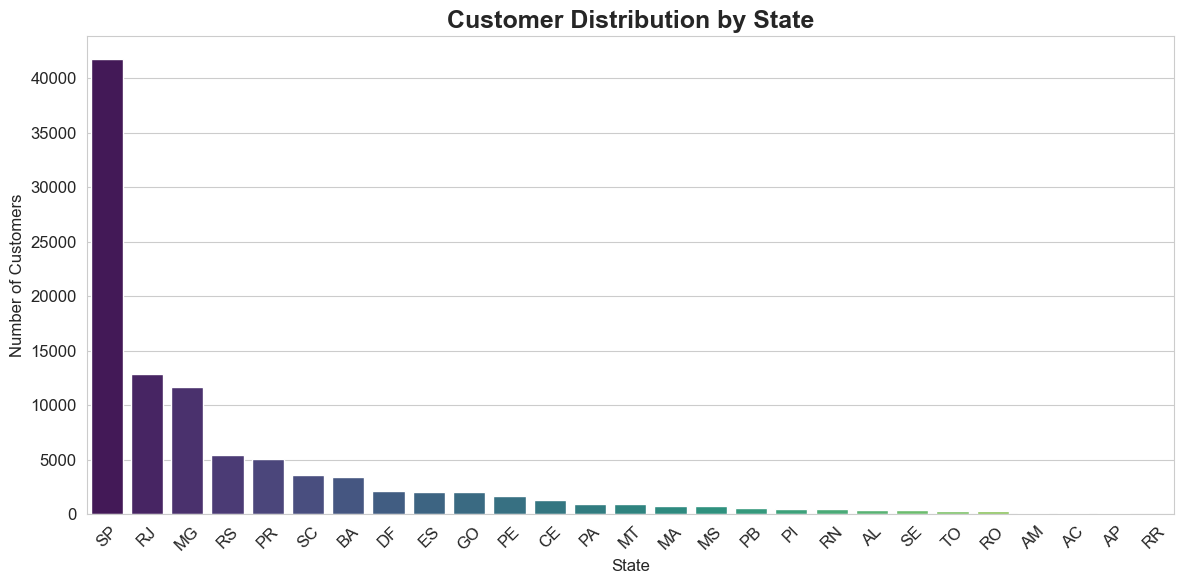

In [3]:
state_counts = customers['customer_state'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_counts.index,
    y=state_counts.values,
    palette="viridis"
)

plt.title("Customer Distribution by State",
          fontsize=18,
          weight='bold')

plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Insights

• São Paulo has the highest number of customers.

• Rio de Janeiro and Minas Gerais are the next largest customer markets.

• The company has a strong customer concentration in the southeast region of Brazil.

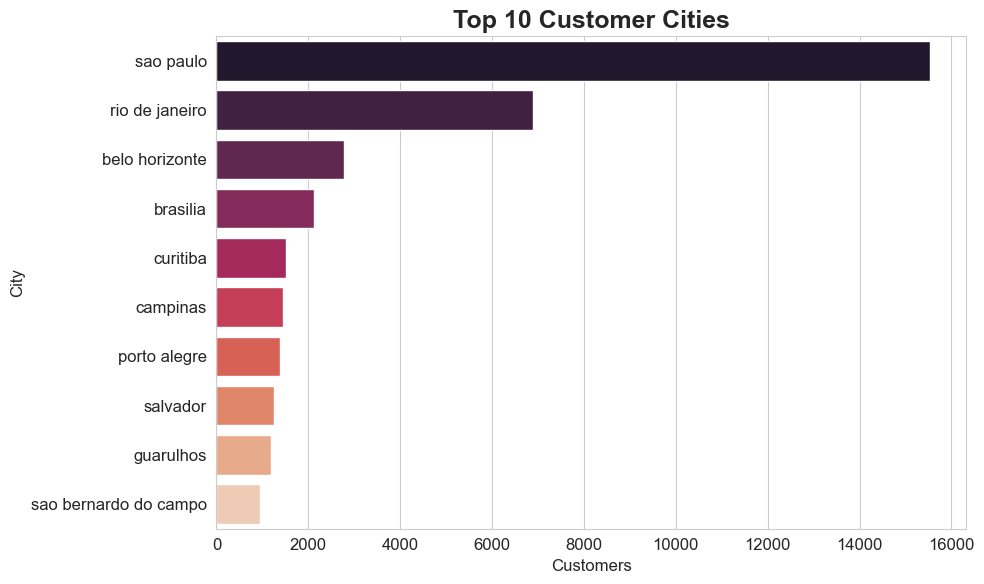

In [4]:
city_counts = customers['customer_city'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=city_counts.values,
    y=city_counts.index,
    palette="rocket"
)

plt.title("Top 10 Customer Cities",
          fontsize=18,
          weight='bold')

plt.xlabel("Customers")
plt.ylabel("City")

plt.tight_layout()

plt.show()

## Insights

• São Paulo city contributes the largest share of customers.

• Major metropolitan cities dominate online shopping activity.

• Marketing campaigns can focus on these high-value cities.

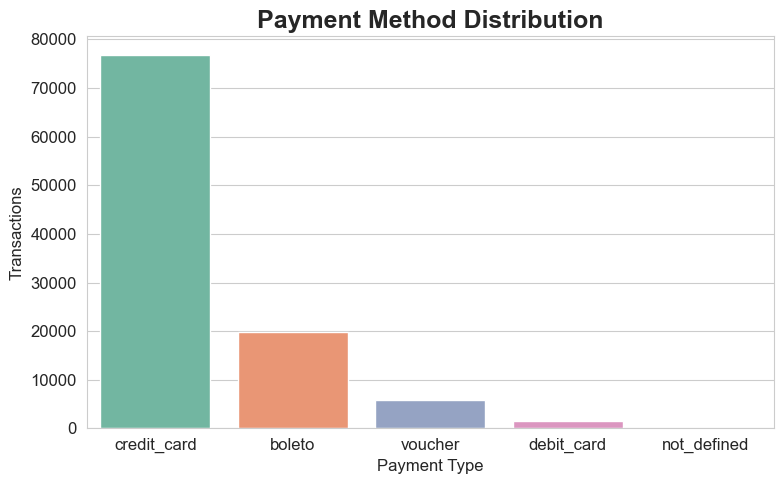

In [5]:
payment_counts = payments['payment_type'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values,
    palette="Set2"
)

plt.title("Payment Method Distribution",
          fontsize=18,
          weight='bold')

plt.xlabel("Payment Type")
plt.ylabel("Transactions")

plt.tight_layout()

plt.show()

## Insights

• Credit cards are the most preferred payment method.

• Boleto is the second most popular payment option.

• Debit cards and vouchers are used by comparatively fewer customers.

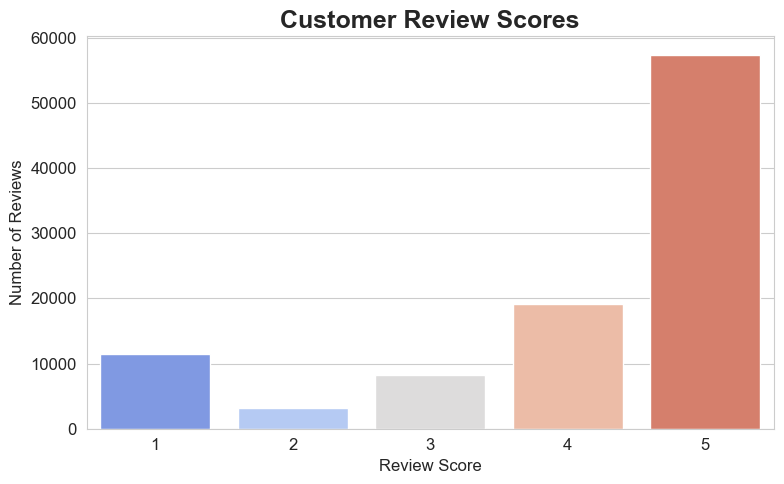

In [6]:
review_counts = reviews['review_score'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=review_counts.index,
    y=review_counts.values,
    palette="coolwarm"
)

plt.title("Customer Review Scores",
          fontsize=18,
          weight='bold')

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

## Insights

• Most customers gave a 5-star rating.

• Low ratings are comparatively fewer.

• Overall customer satisfaction is high.

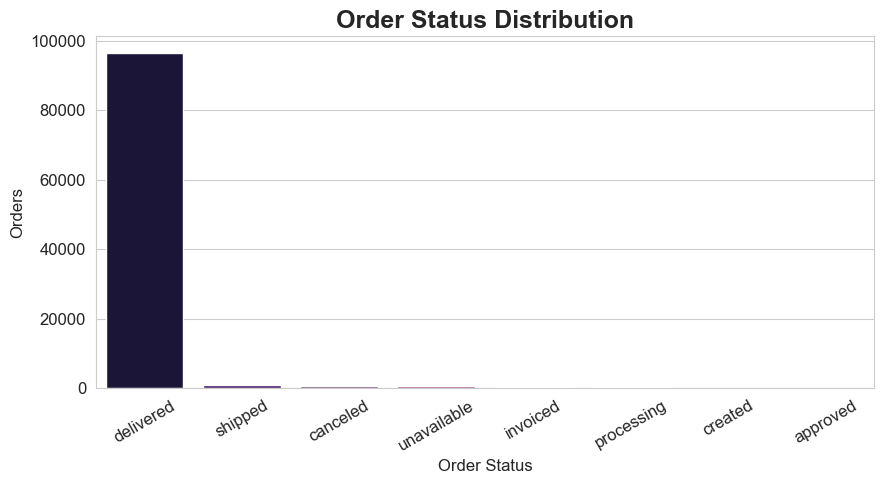

In [7]:
status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(9,5))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    palette="magma"
)

plt.title("Order Status Distribution",
          fontsize=18,
          weight='bold')

plt.xlabel("Order Status")
plt.ylabel("Orders")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

## Insights

• Most orders have been successfully delivered.

• Cancelled and unavailable orders represent only a small portion of total orders.

• The company demonstrates strong order fulfillment performance.

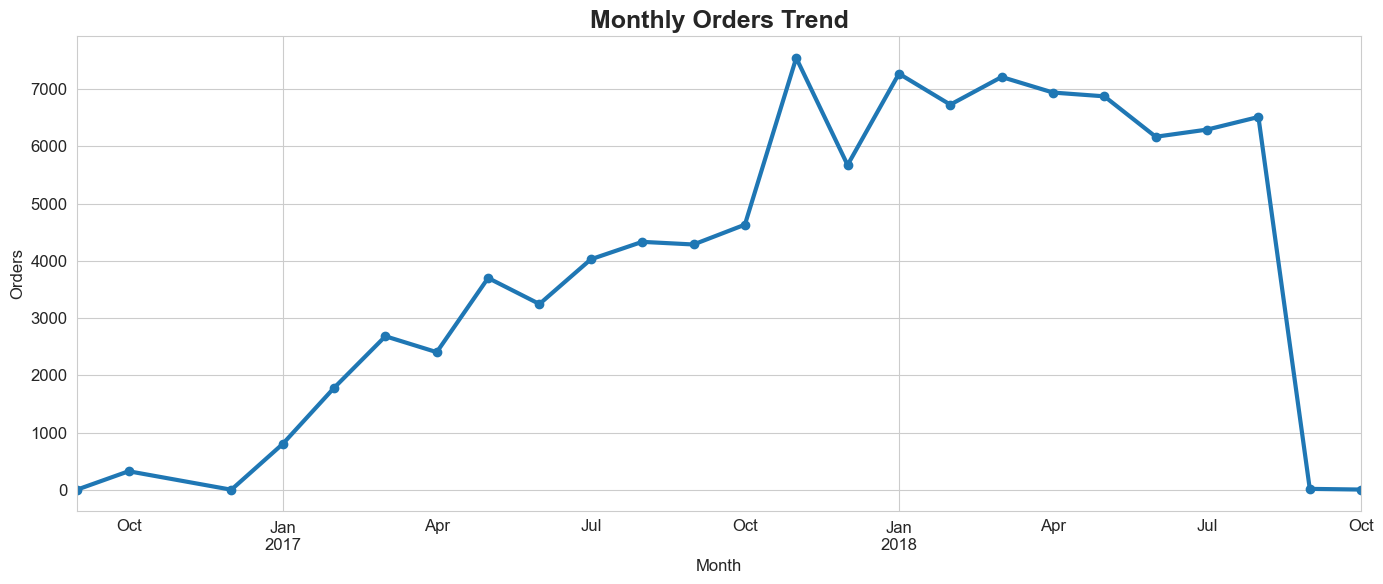

In [8]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['Month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('Month').size()

plt.figure(figsize=(14,6))

monthly_orders.plot(
    marker='o',
    linewidth=3
)

plt.title("Monthly Orders Trend",
          fontsize=18,
          weight='bold')

plt.xlabel("Month")
plt.ylabel("Orders")

plt.grid(True)

plt.tight_layout()

plt.show()

## Insights

• Monthly sales show clear fluctuations over time.

• Some months experience noticeably higher order volumes, indicating seasonal demand.

• These trends can support inventory planning and marketing strategies.

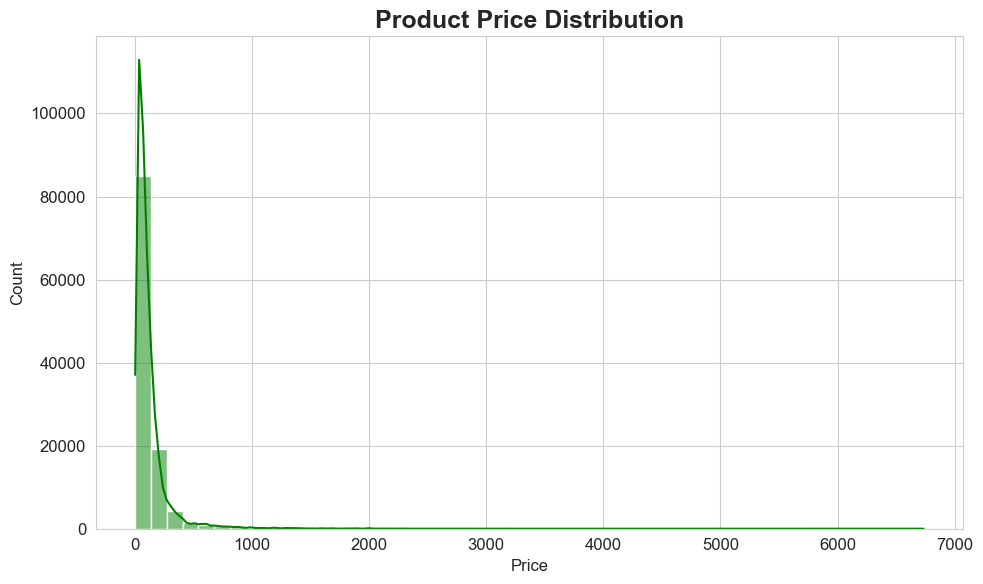

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    order_items['price'],
    bins=50,
    kde=True,
    color='green'
)

plt.title("Product Price Distribution",
          fontsize=18,
          weight='bold')

plt.xlabel("Price")

plt.tight_layout()

plt.show()

## Insights

• Most products are priced in the lower price range.

• High-priced products are relatively rare.

• The business primarily targets affordable consumer products.

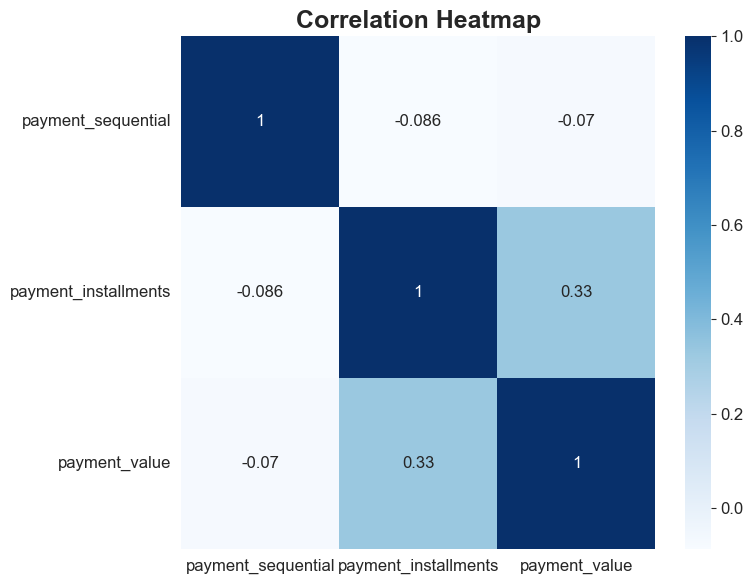

In [10]:
numeric = payments.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap",
          fontsize=18,
          weight='bold')

plt.tight_layout()

plt.show()

## Insights

• Most numeric features show weak correlations.

• Payment value and installment count have a slight positive relationship.

• No strong multicollinearity is observed.

In [11]:
# Merge Orders and Payments
orders_payments = pd.merge(
    orders,
    payments,
    on="order_id",
    how="inner"
)

# Merge Orders and Reviews
orders_reviews = pd.merge(
    orders,
    reviews,
    on="order_id",
    how="inner"
)

# Merge Order Items and Products
product_sales = pd.merge(
    order_items,
    products,
    on="product_id",
    how="inner"
)

print("Orders + Payments:", orders_payments.shape)
print("Orders + Reviews:", orders_reviews.shape)
print("Product Sales:", product_sales.shape)

Orders + Payments: (103886, 13)
Orders + Reviews: (99224, 15)
Product Sales: (112650, 15)


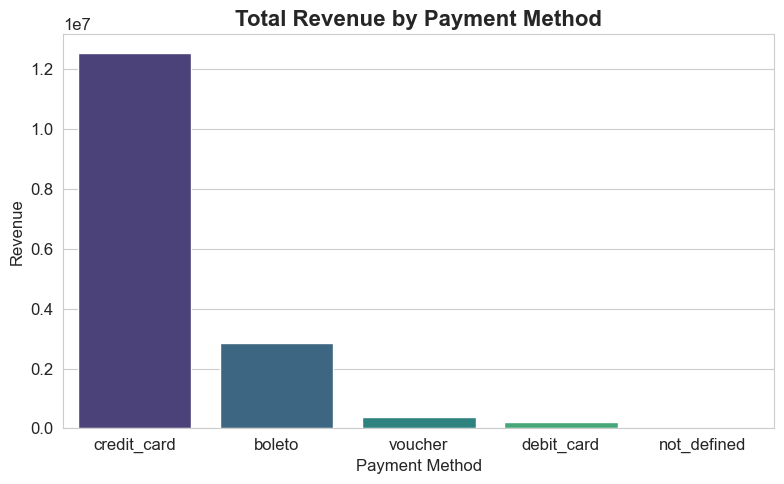

In [12]:
payment_revenue = payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values,
    palette='viridis'
)

plt.title("Total Revenue by Payment Method", fontsize=16, fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Insights

• Credit cards generate the highest revenue.

• Boleto contributes significantly but is lower than credit cards.

• Voucher and debit card transactions contribute a smaller share of total revenue.

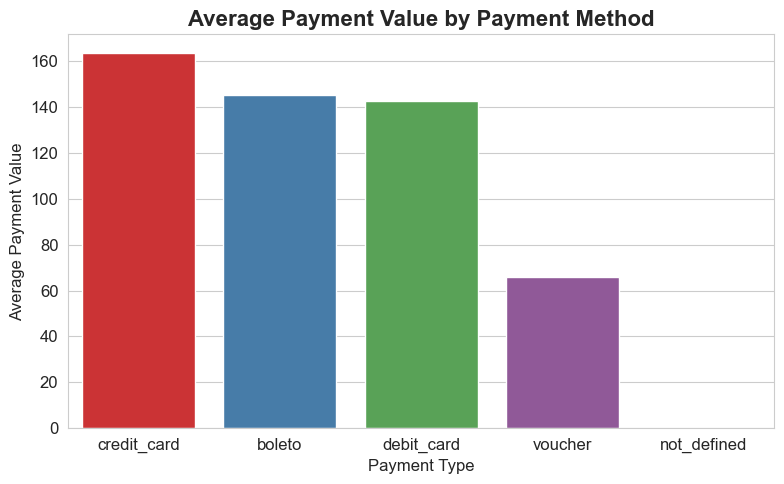

In [13]:
avg_payment = payments.groupby("payment_type")["payment_value"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_payment.index,
    y=avg_payment.values,
    palette="Set1"
)

plt.title("Average Payment Value by Payment Method",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Payment Type")
plt.ylabel("Average Payment Value")

plt.tight_layout()

plt.show()

## Insights

• Customers using credit cards generally spend more per transaction.

• Voucher and debit card users tend to have lower average purchase values.

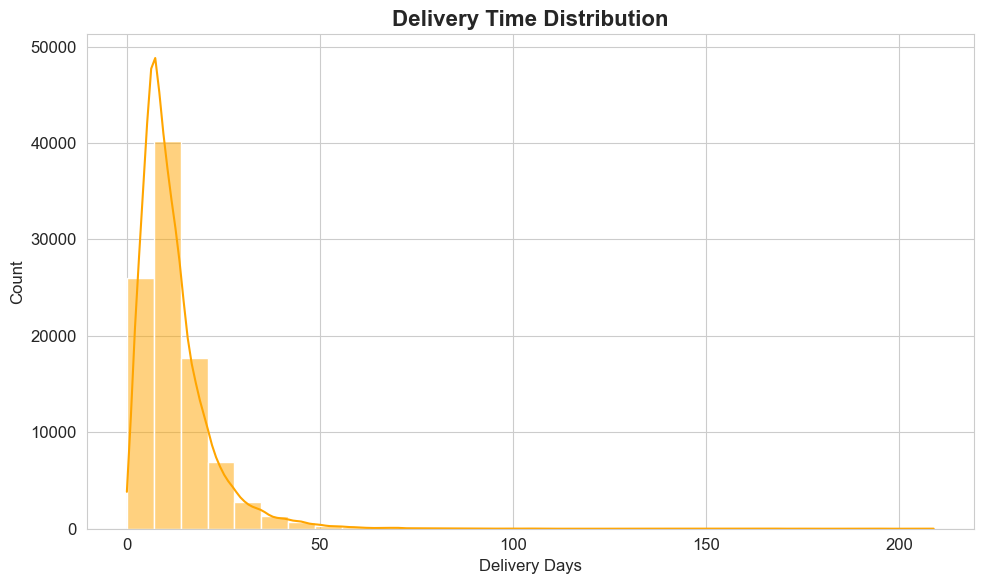

In [14]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

plt.figure(figsize=(10,6))

sns.histplot(
    orders['delivery_days'].dropna(),
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Delivery Time Distribution",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Delivery Days")

plt.tight_layout()

plt.show()

## Insights

• Most deliveries are completed within a few days.

• A small number of orders experience longer delivery times.

• Monitoring delayed deliveries can improve customer satisfaction.